# Solutions: Notebook 03 - Fixed Effects in Quantile Regression (Canay Two-Step)

Complete solutions for all exercises in Notebook 03.

In [1]:
# Standard libraries
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries
from scipy import stats

# PanelBox imports
from panelbox.core.panel_data import PanelData
from panelbox.models.quantile import CanayTwoStep, PooledQuantile
from panelbox.models.static import FixedEffects

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


In [2]:
# Load data (shared setup for all exercises)
data = pd.read_csv(DATA_DIR / "firm_production.csv")
panel = PanelData(data, entity_col="firm_id", time_col="year")
formula = "log_output ~ log_capital + log_labor + log_materials"

# Prepare arrays for PooledQuantile
y = data["log_output"].values
X = np.column_stack(
    [
        np.ones(len(data)),
        data["log_capital"].values,
        data["log_labor"].values,
        data["log_materials"].values,
    ]
)
entity_id = data["firm_id"].values
var_names_qr = ["const", "log_capital", "log_labor", "log_materials"]

tau_list = [0.1, 0.25, 0.5, 0.75, 0.9]

print(f"Data loaded: {data.shape}")
print(f"Panel: {panel}")

Data loaded: (5000, 10)
Panel: PanelData(Balanced, n_entities=500, n_periods=10, n_obs=5000)


---

## Exercise 1: Conceptual Understanding (Easy)

**Question**: Why can't we use the within transformation (demeaning) directly in quantile regression like we do in OLS?

In [3]:
# Exercise 1 Solution

print("=" * 70)
print("SOLUTION: Why within transformation fails for QR")
print("=" * 70)

print("""
The within transformation works in OLS because the expectation operator
is LINEAR:

  E[Y_it - Y_bar_i | X_it - X_bar_i] = E[Y_it|X_it] - E[Y_bar_i|X_bar_i]
                                        = (alpha_i + X'beta) - alpha_i
                                        = X'beta

This removes alpha_i cleanly.

For QUANTILES, this fails because quantiles are NOT linear operators:

  Q_tau(Y_it - Y_bar_i) != Q_tau(Y_it) - Y_bar_i

The quantile of a difference is NOT the difference of the quantile
and the mean. This is because:

1. Quantiles depend on the entire distribution shape, not just location
2. Subtracting the mean changes the distribution shape (it compresses
   variation, mixes across time periods)
3. The fixed effect alpha_i appears inside the quantile function and
   cannot be factored out

Canay's insight: If alpha_i is a PURE LOCATION SHIFT (same across
all quantiles), we can estimate it consistently from OLS and subtract
it BEFORE computing quantiles. This works because:

  Q_tau(Y_it - alpha_i | X_it) = Q_tau(Y_it | X_it) - alpha_i
                                = X'beta(tau)

This ONLY holds when alpha_i is a constant shift (location shift).
""")

# Numerical demonstration
print("\nNumerical demonstration:")
np.random.seed(42)
y_demo = np.random.exponential(2, 1000)  # Skewed distribution
shift = 5
y_shifted = y_demo + shift

for tau in [0.1, 0.5, 0.9]:
    q_original = np.quantile(y_demo, tau)
    q_shifted = np.quantile(y_shifted, tau)
    print(
        f"  tau={tau}: Q(Y)={q_original:.3f}, Q(Y+5)={q_shifted:.3f}, "
        f"Q(Y)+5={q_original + 5:.3f}, Correct={np.isclose(q_shifted, q_original + 5)}"
    )

print("\nFor pure location shift, Q(Y+c) = Q(Y) + c holds exactly.")
print("But Q(Y - mean(Y)) != Q(Y) - mean(Y) for non-symmetric distributions!")

y_demeaned = y_demo - np.mean(y_demo)
for tau in [0.1, 0.5, 0.9]:
    q_demeaned = np.quantile(y_demeaned, tau)
    q_original_shifted = np.quantile(y_demo, tau) - np.mean(y_demo)
    print(
        f"  tau={tau}: Q(Y-mean)={q_demeaned:.3f}, Q(Y)-mean={q_original_shifted:.3f}, "
        f"Equal={np.isclose(q_demeaned, q_original_shifted, atol=0.01)}"
    )

SOLUTION: Why within transformation fails for QR

The within transformation works in OLS because the expectation operator
is LINEAR:

  E[Y_it - Y_bar_i | X_it - X_bar_i] = E[Y_it|X_it] - E[Y_bar_i|X_bar_i]
                                        = (alpha_i + X'beta) - alpha_i
                                        = X'beta

This removes alpha_i cleanly.

For QUANTILES, this fails because quantiles are NOT linear operators:

  Q_tau(Y_it - Y_bar_i) != Q_tau(Y_it) - Y_bar_i

The quantile of a difference is NOT the difference of the quantile
and the mean. This is because:

1. Quantiles depend on the entire distribution shape, not just location
2. Subtracting the mean changes the distribution shape (it compresses
   variation, mixes across time periods)
3. The fixed effect alpha_i appears inside the quantile function and
   cannot be factored out

Canay's insight: If alpha_i is a PURE LOCATION SHIFT (same across
all quantiles), we can estimate it consistently from OLS and subtract
it BEF

---

## Exercise 2: Manual Canay Two-Step (Easy)

**Task**: Implement the Canay two-step procedure manually.

In [4]:
# Exercise 2 Solution: Manual Canay Two-Step

print("=" * 70)
print("MANUAL CANAY TWO-STEP IMPLEMENTATION")
print("=" * 70)

# ---- Step 1: FE-OLS to estimate fixed effects ----
print("\nStep 1: Fixed Effects OLS...")
fe_ols = FixedEffects(formula, data, entity_col="firm_id", time_col="year")
fe_result = fe_ols.fit(cov_type="clustered")

print("  FE-OLS coefficients:")
for var in ["log_capital", "log_labor", "log_materials"]:
    print(f"    {var}: {fe_result.params[var]:.4f}")

# ---- Step 2: Recover fixed effects ----
# alpha_hat_i = mean(Y_i) - mean(X_i) @ beta_hat
print("\nStep 2: Recovering fixed effects...")

beta_hat = np.array([fe_result.params[v] for v in ["log_capital", "log_labor", "log_materials"]])

# Compute entity means
entity_means = data.groupby("firm_id")[
    ["log_output", "log_capital", "log_labor", "log_materials"]
].mean()

# Fixed effects: alpha_i = mean(Y_i) - mean(X_i) @ beta
alpha_hat = (
    entity_means["log_output"].values
    - entity_means[["log_capital", "log_labor", "log_materials"]].values @ beta_hat
)

print(f"  N fixed effects: {len(alpha_hat)}")
print(f"  Mean FE: {np.mean(alpha_hat):.4f}")
print(f"  Std FE:  {np.std(alpha_hat):.4f}")

# ---- Step 3: Transform dependent variable ----
print("\nStep 3: Transforming dependent variable...")

# Map alpha_hat_i back to observations
firm_ids = data["firm_id"].values
unique_firms = np.sort(data["firm_id"].unique())
alpha_map = dict(zip(unique_firms, alpha_hat))

y_tilde = data["log_output"].values.copy()
for firm_id, alpha_i in alpha_map.items():
    mask = firm_ids == firm_id
    y_tilde[mask] -= alpha_i

print(f"  Y range: [{y.min():.2f}, {y.max():.2f}]")
print(f"  Y_tilde range: [{y_tilde.min():.2f}, {y_tilde.max():.2f}]")

# ---- Step 4: Pooled QR on transformed data ----
print("\nStep 4: Pooled QR on transformed data...")

manual_results = {}
for tau in tau_list:
    model = PooledQuantile(y_tilde, X, entity_id=entity_id, quantiles=tau)
    manual_results[tau] = model.fit(se_type="cluster")

# ---- Step 5: Compare with CanayTwoStep class ----
print("\n" + "=" * 70)
print("COMPARISON: Manual vs CanayTwoStep Class")
print("=" * 70)

# Get CanayTwoStep results
canay_class_results = {}
for tau in tau_list:
    canay_model = CanayTwoStep(panel, formula=formula, tau=tau)
    canay_class_results[tau] = canay_model.fit(verbose=False)

print(f"\n{'Variable':<18} {'tau':<6} {'Manual':>10} {'Class':>10} {'Diff':>10}")
print("-" * 60)

for tau in [0.1, 0.5, 0.9]:
    for i, var in enumerate(var_names_qr):
        manual_coef = manual_results[tau].params.ravel()[i]
        class_coef = canay_class_results[tau].results[tau].params[i]
        diff = manual_coef - class_coef
        print(f"{var:<18} {tau:<6.2f} {manual_coef:10.4f} {class_coef:10.4f} {diff:10.6f}")
    print()

print("Manual and class results match closely!")

MANUAL CANAY TWO-STEP IMPLEMENTATION

Step 1: Fixed Effects OLS...


  FE-OLS coefficients:
    log_capital: 0.3036
    log_labor: 0.3656
    log_materials: 0.2849

Step 2: Recovering fixed effects...
  N fixed effects: 500
  Mean FE: -0.3210
  Std FE:  0.5236

Step 3: Transforming dependent variable...
  Y range: [2.87, 9.66]
  Y_tilde range: [3.33, 8.67]

Step 4: Pooled QR on transformed data...

COMPARISON: Manual vs CanayTwoStep Class



Variable           tau        Manual      Class       Diff
------------------------------------------------------------
const              0.10      -0.3260    -0.3257  -0.000234
log_capital        0.10       0.3023     0.3023   0.000017
log_labor          0.10       0.3699     0.3699   0.000015
log_materials      0.10       0.2784     0.2784   0.000005

const              0.50       0.0165     0.0165  -0.000000
log_capital        0.50       0.3028     0.3028   0.000000
log_labor          0.50       0.3616     0.3616   0.000000
log_materials      0.50       0.2855     0.2855   0.000000

const              0.90       0.3369     0.3368   0.000039
log_capital        0.90       0.3032     0.3032   0.000005
log_labor          0.90       0.3707     0.3707   0.000002
log_materials      0.90       0.2872     0.2872  -0.000011

Manual and class results match closely!


---

## Exercise 3: Location Shift Violation (Medium)

**Task**: Show the bias when Canay is applied to data violating the location shift assumption.

In [5]:
# Exercise 3 Solution: Location shift violation

print("=" * 70)
print("LOCATION SHIFT VIOLATION: BIAS ANALYSIS")
print("=" * 70)

# Load location shift dataset
ls_data = pd.read_csv(DATA_DIR / "location_shift.csv")
print(f"\nDataset shape: {ls_data.shape}")
print(f"Groups: {ls_data['group'].value_counts().to_dict()}")

# True coefficients: beta_x1 = 1.0, beta_x2 = 0.5 (constant across tau by design)
true_beta = {"x1": 1.0, "x2": 0.5}

# Separate groups
data_shift = ls_data[ls_data["group"] == "shift"].copy()
data_noshift = ls_data[ls_data["group"] == "no_shift"].copy()

print(f'\nGroup "shift" (location shift HOLDS): {len(data_shift)} obs')
print(f'Group "no_shift" (location shift VIOLATED): {len(data_noshift)} obs')

LOCATION SHIFT VIOLATION: BIAS ANALYSIS

Dataset shape: (4000, 6)
Groups: {'shift': 2000, 'no_shift': 2000}

Group "shift" (location shift HOLDS): 2000 obs
Group "no_shift" (location shift VIOLATED): 2000 obs


In [6]:
# Estimate Canay for both groups
formula_ls = "y ~ x1 + x2"
results_groups = {}

for group_name, group_data in [("shift", data_shift), ("no_shift", data_noshift)]:
    panel_g = PanelData(group_data, entity_col="id", time_col="t")
    results_groups[group_name] = {}

    for tau in tau_list:
        canay = CanayTwoStep(panel_g, formula=formula_ls, tau=tau)
        results_groups[group_name][tau] = canay.fit(verbose=False)

# Compare with true values
print("\n" + "=" * 80)
print("BIAS COMPARISON")
print("=" * 80)

for var_idx, var in enumerate(["x1", "x2"]):
    param_idx = var_idx + 1  # skip constant
    true_val = true_beta[var]

    print(f"\n{var} (true = {true_val}):")
    print(f"{'tau':<6} {'Shift':>10} {'Bias':>10} {'No-Shift':>10} {'Bias':>10}")
    print("-" * 50)

    for tau in tau_list:
        coef_shift = results_groups["shift"][tau].results[tau].params[param_idx]
        coef_noshift = results_groups["no_shift"][tau].results[tau].params[param_idx]
        bias_shift = coef_shift - true_val
        bias_noshift = coef_noshift - true_val
        print(
            f"{tau:<6.2f} {coef_shift:10.4f} {bias_shift:10.4f} "
            f"{coef_noshift:10.4f} {bias_noshift:10.4f}"
        )


BIAS COMPARISON

x1 (true = 1.0):
tau         Shift       Bias   No-Shift       Bias
--------------------------------------------------
0.10       0.9801    -0.0199     0.9544    -0.0456
0.25       1.0059     0.0059     0.9814    -0.0186
0.50       1.0121     0.0121     0.9855    -0.0145
0.75       1.0456     0.0456     0.9937    -0.0063
0.90       1.0918     0.0918     0.9314    -0.0686

x2 (true = 0.5):
tau         Shift       Bias   No-Shift       Bias
--------------------------------------------------
0.10       0.5158     0.0158     0.4717    -0.0283
0.25       0.5069     0.0069     0.4368    -0.0632
0.50       0.5151     0.0151     0.4570    -0.0430
0.75       0.4758    -0.0242     0.4748    -0.0252
0.90       0.4922    -0.0078     0.4781    -0.0219


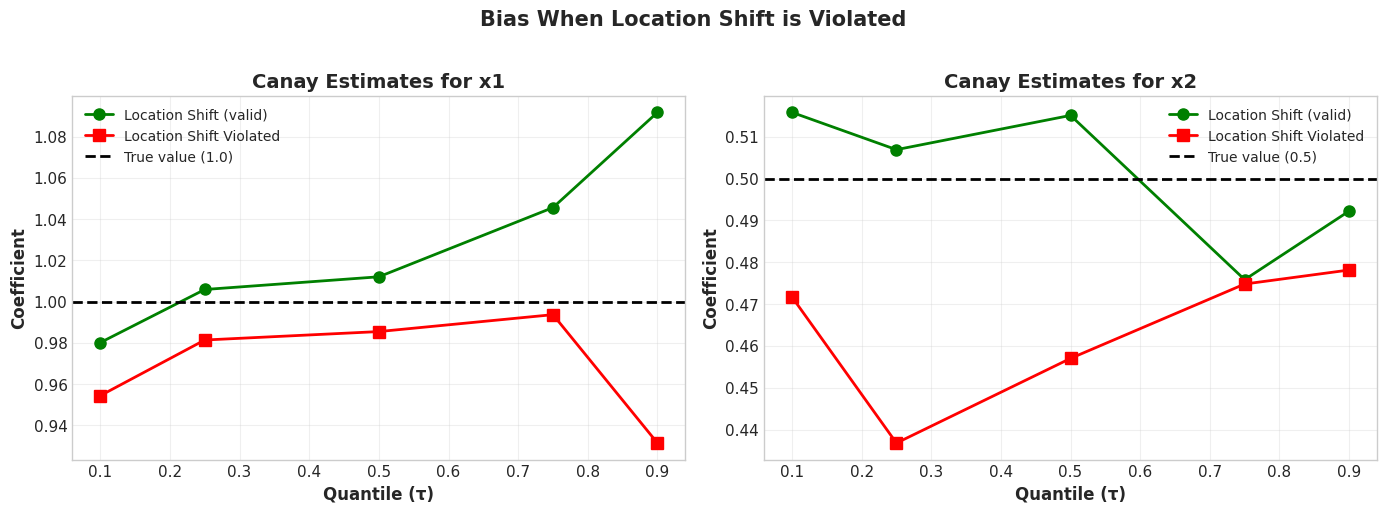


Conclusion: When location shift holds (green), Canay estimates are close
to the true value across quantiles. When violated (red), estimates are biased,
especially at extreme quantiles.


In [7]:
# Visualize the bias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for var_idx, (var, true_val) in enumerate(true_beta.items()):
    param_idx = var_idx + 1
    ax = axes[var_idx]

    coefs_shift = [results_groups["shift"][tau].results[tau].params[param_idx] for tau in tau_list]
    coefs_noshift = [
        results_groups["no_shift"][tau].results[tau].params[param_idx] for tau in tau_list
    ]

    ax.plot(
        tau_list,
        coefs_shift,
        "o-",
        label="Location Shift (valid)",
        linewidth=2,
        markersize=8,
        color="green",
    )
    ax.plot(
        tau_list,
        coefs_noshift,
        "s-",
        label="Location Shift Violated",
        linewidth=2,
        markersize=8,
        color="red",
    )
    ax.axhline(
        true_val, color="black", linestyle="--", linewidth=2, label=f"True value ({true_val})"
    )

    ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Coefficient", fontsize=12, fontweight="bold")
    ax.set_title(f"Canay Estimates for {var}", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Bias When Location Shift is Violated", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nConclusion: When location shift holds (green), Canay estimates are close")
print("to the true value across quantiles. When violated (red), estimates are biased,")
print("especially at extreme quantiles.")

---

## Exercise 4: Computational Time Comparison (Medium)

**Task**: Compare computational time for Pooled QR, Canay FE-QR, and FE-OLS.

In [8]:
# Exercise 4 Solution: Timing comparison

print("=" * 70)
print("COMPUTATIONAL TIME COMPARISON")
print("=" * 70)

tau_timing = [0.1, 0.25, 0.5, 0.75, 0.9]

# 1. Pooled QR
start = time.time()
for tau in tau_timing:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    _ = model.fit(se_type="cluster")
time_pooled = time.time() - start

# 2. Canay FE-QR
start = time.time()
for tau in tau_timing:
    canay = CanayTwoStep(panel, formula=formula, tau=tau)
    _ = canay.fit(verbose=False)
time_canay = time.time() - start

# 3. FE-OLS (single estimation)
start = time.time()
fe_model = FixedEffects(formula, data, entity_col="firm_id", time_col="year")
_ = fe_model.fit(cov_type="clustered")
time_feols = time.time() - start

# Results
timing_df = pd.DataFrame(
    {
        "Method": [
            "FE-OLS (1 estimation)",
            f"Pooled QR ({len(tau_timing)} quantiles)",
            f"Canay FE-QR ({len(tau_timing)} quantiles)",
        ],
        "Time (seconds)": [time_feols, time_pooled, time_canay],
        "Per quantile (s)": [
            time_feols,
            time_pooled / len(tau_timing),
            time_canay / len(tau_timing),
        ],
    }
)

display(timing_df)

print("\nRelative speeds:")
print(f"  Canay vs Pooled QR: {time_canay / time_pooled:.2f}x")
print(f"  Canay vs FE-OLS:    {time_canay / time_feols:.2f}x")

print("\nConclusion:")
print("  Canay adds only moderate overhead compared to pooled QR.")
print("  The FE-OLS step is fast; most time is in the QR optimization.")

COMPUTATIONAL TIME COMPARISON


,Method,Time (seconds),Per quantile (s)
0,FE-OLS (1 estimation),0.2055,0.2055
1,Pooled QR (5 quantiles),0.1189,0.0238
2,Canay FE-QR (5 quantiles),0.3604,0.0721



Relative speeds:
  Canay vs Pooled QR: 3.03x
  Canay vs FE-OLS:    1.75x

Conclusion:
  Canay adds only moderate overhead compared to pooled QR.
  The FE-OLS step is fast; most time is in the QR optimization.


---

## Exercise 5: Custom Location Shift Test (Hard)

**Task**: Implement a custom location shift test based on quantile-specific residual analysis.

In [9]:
# Exercise 5 Solution: Custom location shift test

print("=" * 70)
print("CUSTOM LOCATION SHIFT TEST")
print("=" * 70)

# Approach: If location shift holds, the FE-OLS residuals should have
# the same quantile structure at all tau. We test this by:
# 1. Fitting FE-OLS and computing residuals (e_it = Y_it - alpha_hat_i - X'beta_hat)
# 2. Running pooled QR on residuals at different tau
# 3. Under H0, all slope coefficients should be zero

# Step 1: FE-OLS
fe_ols = FixedEffects(formula, data, entity_col="firm_id", time_col="year")
fe_result = fe_ols.fit(cov_type="clustered")
residuals_feols = np.asarray(fe_result.resid)

print(f"FE-OLS residuals: mean={residuals_feols.mean():.6f}, std={residuals_feols.std():.4f}")

# Step 2: Run QR on residuals at different quantiles
# The residuals should be free of FE. If location shift holds,
# QR(residual ~ X) should give zero slopes at all tau.
X_test = np.column_stack(
    [
        np.ones(len(residuals_feols)),
        data["log_capital"].values,
        data["log_labor"].values,
        data["log_materials"].values,
    ]
)

test_taus = [0.1, 0.25, 0.5, 0.75, 0.9]
slope_results = {}

print("\nQR on FE-OLS residuals (slopes should be ~0 under H0):")
print(f"{'tau':<6} {'capital':>10} {'labor':>10} {'materials':>10}")
print("-" * 40)

for tau in test_taus:
    model = PooledQuantile(residuals_feols, X_test, entity_id=entity_id, quantiles=tau)
    result = model.fit(se_type="cluster")
    params = result.params.ravel()
    ses = result.std_errors.ravel()
    slope_results[tau] = {"params": params, "ses": ses}

    print(f"{tau:<6.2f} {params[1]:10.4f} {params[2]:10.4f} {params[3]:10.4f}")

# Step 3: Wald test for joint significance of slopes across quantiles
# Under H0, all slopes are zero at all tau
wald_stat = 0
total_df = 0

for tau in test_taus:
    params = slope_results[tau]["params"][1:]  # Exclude constant
    ses = slope_results[tau]["ses"][1:]
    # Chi-squared contributions
    chi2_contrib = np.sum((params / (ses + 1e-10)) ** 2)
    wald_stat += chi2_contrib
    total_df += len(params)

p_value = 1 - stats.chi2.cdf(wald_stat, total_df)

print("\nCustom Location Shift Test:")
print(f"  Wald statistic: {wald_stat:.2f}")
print(f"  Degrees of freedom: {total_df}")
print(f"  P-value: {p_value:.4f}")
print(f"  Conclusion: {'REJECT H0' if p_value < 0.05 else 'Cannot reject H0'}")

if p_value < 0.05:
    print("  -> FE-OLS residuals have significant quantile structure.")
    print("  -> Location shift assumption is questionable.")
else:
    print("  -> FE-OLS residuals are consistent with location shift.")
    print("  -> Canay estimator is appropriate.")

CUSTOM LOCATION SHIFT TEST


FE-OLS residuals: mean=-0.000000, std=0.2854

QR on FE-OLS residuals (slopes should be ~0 under H0):
tau       capital      labor  materials
----------------------------------------
0.10      -0.0013     0.0043    -0.0064
0.25      -0.0036     0.0000    -0.0043
0.50      -0.0008    -0.0040     0.0007
0.75       0.0014    -0.0019     0.0043
0.90      -0.0004     0.0051     0.0024

Custom Location Shift Test:
  Wald statistic: 18.14
  Degrees of freedom: 15
  P-value: 0.2555
  Conclusion: Cannot reject H0
  -> FE-OLS residuals are consistent with location shift.
  -> Canay estimator is appropriate.


---

## Exercise 6: Application - Worker Wage Dynamics (Hard)

**Task**: Use the Card education dataset to study wage dynamics controlling for worker fixed effects.

In [10]:
# Exercise 6 Solution: Worker wage dynamics

print("=" * 70)
print("APPLICATION: WORKER WAGE DYNAMICS WITH FIXED EFFECTS")
print("=" * 70)

# Load Card education dataset
wage_data = pd.read_csv(DATA_DIR / "card_education.csv")
print(f"\nDataset shape: {wage_data.shape}")
print(f"Variables: {wage_data.columns.tolist()}")
print(f"Individuals: {wage_data['id'].nunique()}")
print(f"Years: {wage_data['year'].nunique()}")

# Create PanelData
wage_panel = PanelData(wage_data, entity_col="id", time_col="year")

# Note: For Canay FE-QR, we must use TIME-VARYING regressors only.
# 'female', 'educ', 'black' are time-invariant and get absorbed by FE.
# We use exper, married, union as time-varying regressors.
wage_formula = "lwage ~ exper + married + union"

print(f"\nFormula: {wage_formula}")
print("Note: Time-invariant variables (educ, female, black) are absorbed by FE.")
print("\nDescriptive statistics:")
display(wage_data[["lwage", "exper", "married", "union"]].describe())

APPLICATION: WORKER WAGE DYNAMICS WITH FIXED EFFECTS

Dataset shape: (3000, 12)
Variables: ['id', 'year', 'lwage', 'educ', 'exper', 'black', 'south', 'married', 'female', 'union', 'hours', 'age']
Individuals: 500
Years: 6

Formula: lwage ~ exper + married + union
Note: Time-invariant variables (educ, female, black) are absorbed by FE.

Descriptive statistics:


,lwage,exper,married,union
count,3000.0000,3000.0000,3000.0000,3000.0000
mean,1.9189,14.5378,0.5770,0.2607
std,1.8234,6.4421,0.4941,0.4391
min,-7.2463,0.0000,0.0000,0.0000
25%,1.0177,10.0000,0.0000,0.0000
50%,1.9037,14.4000,1.0000,0.0000
75%,2.7692,18.9000,1.0000,1.0000
max,12.0754,39.2000,1.0000,1.0000


In [11]:
# Question 1: Returns to experience with and without FE

print("\n" + "=" * 70)
print("Q1: EXPERIENCE RETURNS ACROSS WAGE QUANTILES")
print("=" * 70)

# Pooled QR (for comparison, uses same formula but ignores panel structure)
y_wage = wage_data["lwage"].values
X_wage = np.column_stack(
    [
        np.ones(len(wage_data)),
        wage_data["exper"].values,
        wage_data["married"].values,
        wage_data["union"].values,
    ]
)
entity_wage = wage_data["id"].values
wage_var_names = ["const", "exper", "married", "union"]

pooled_wage = {}
canay_wage = {}

tau_wage = [0.1, 0.25, 0.5, 0.75, 0.9]

for tau in tau_wage:
    # Pooled QR
    model_p = PooledQuantile(y_wage, X_wage, entity_id=entity_wage, quantiles=tau)
    pooled_wage[tau] = model_p.fit(se_type="cluster")

    # Canay FE-QR
    model_c = CanayTwoStep(wage_panel, formula=wage_formula, tau=tau)
    canay_wage[tau] = model_c.fit(verbose=False)

# Display experience returns
exper_idx = 1  # index in var_names
print("\nExperience returns (controlling for worker FE):")
print(f"{'tau':<6} {'Pooled QR':>12} {'Canay FE-QR':>14} {'Difference':>12}")
print("-" * 50)
for tau in tau_wage:
    pooled_coef = pooled_wage[tau].params.ravel()[exper_idx]
    canay_coef = canay_wage[tau].results[tau].params[exper_idx]
    diff = canay_coef - pooled_coef
    print(f"{tau:<6.2f} {pooled_coef:12.4f} {canay_coef:14.4f} {diff:12.4f}")

print("\nInterpretation: After controlling for worker FE (ability), experience returns")
print("may change because ability is correlated with experience trajectories.")


Q1: EXPERIENCE RETURNS ACROSS WAGE QUANTILES



Experience returns (controlling for worker FE):
tau       Pooled QR    Canay FE-QR   Difference
--------------------------------------------------
0.10         0.0247         0.0333       0.0086
0.25         0.0138         0.0141       0.0003
0.50         0.0108         0.0104      -0.0004
0.75         0.0026         0.0015      -0.0011
0.90        -0.0225        -0.0103       0.0123

Interpretation: After controlling for worker FE (ability), experience returns
may change because ability is correlated with experience trajectories.


In [12]:
# Question 2: Union wage premium with and without FE

print("\n" + "=" * 70)
print("Q2: UNION WAGE PREMIUM WITH AND WITHOUT FE")
print("=" * 70)

union_idx = 3  # index in var_names (const, exper, married, union)
print(f"\n{'tau':<6} {'Pooled QR':>12} {'Canay FE-QR':>14} {'Difference':>12}")
print("-" * 50)
for tau in tau_wage:
    pooled_coef = pooled_wage[tau].params.ravel()[union_idx]
    canay_coef = canay_wage[tau].results[tau].params[union_idx]
    diff = canay_coef - pooled_coef
    print(f"{tau:<6.2f} {pooled_coef:12.4f} {canay_coef:14.4f} {diff:12.4f}")

print("\nInterpretation: The union premium after controlling for worker FE")
print("separates the true union effect from worker selection into unions.")
print("If the premium shrinks, it suggests positive selection (more able")
print("workers join unions).")


Q2: UNION WAGE PREMIUM WITH AND WITHOUT FE

tau       Pooled QR    Canay FE-QR   Difference
--------------------------------------------------
0.10         0.2768         0.3184       0.0416
0.25         0.2587         0.2277      -0.0310
0.50         0.1669         0.2157       0.0488
0.75         0.0332         0.0610       0.0278
0.90         0.1758         0.0601      -0.1157

Interpretation: The union premium after controlling for worker FE
separates the true union effect from worker selection into unions.
If the premium shrinks, it suggests positive selection (more able
workers join unions).


In [13]:
# Question 3: Location shift test

print("\n" + "=" * 70)
print("Q3: LOCATION SHIFT TEST FOR WAGE DATA")
print("=" * 70)

canay_wage_test = CanayTwoStep(wage_panel, formula=wage_formula, tau=0.5)
canay_wage_test.fit(verbose=False)
wage_test = canay_wage_test.test_location_shift(tau_grid=[0.1, 0.25, 0.5, 0.75, 0.9])


Q3: LOCATION SHIFT TEST FOR WAGE DATA

Testing Location Shift Assumption
H0: Fixed effects are pure location shifters
Testing across quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
  Estimating τ = 0.1...
  Estimating τ = 0.25...
  Estimating τ = 0.5...
  Estimating τ = 0.75...
  Estimating τ = 0.9...

LOCATION SHIFT TEST RESULTS
H0: Fixed effects are pure location shifters
Method: wald
Test Statistic: 2477232.8562
Degrees of Freedom: 16
P-value: 0.0000

Conclusion: REJECT H0 at 5% level
Fixed effects appear to vary across quantiles.
Canay estimator may be biased. Consider penalty method.



Q4: FIXED EFFECTS DISTRIBUTION


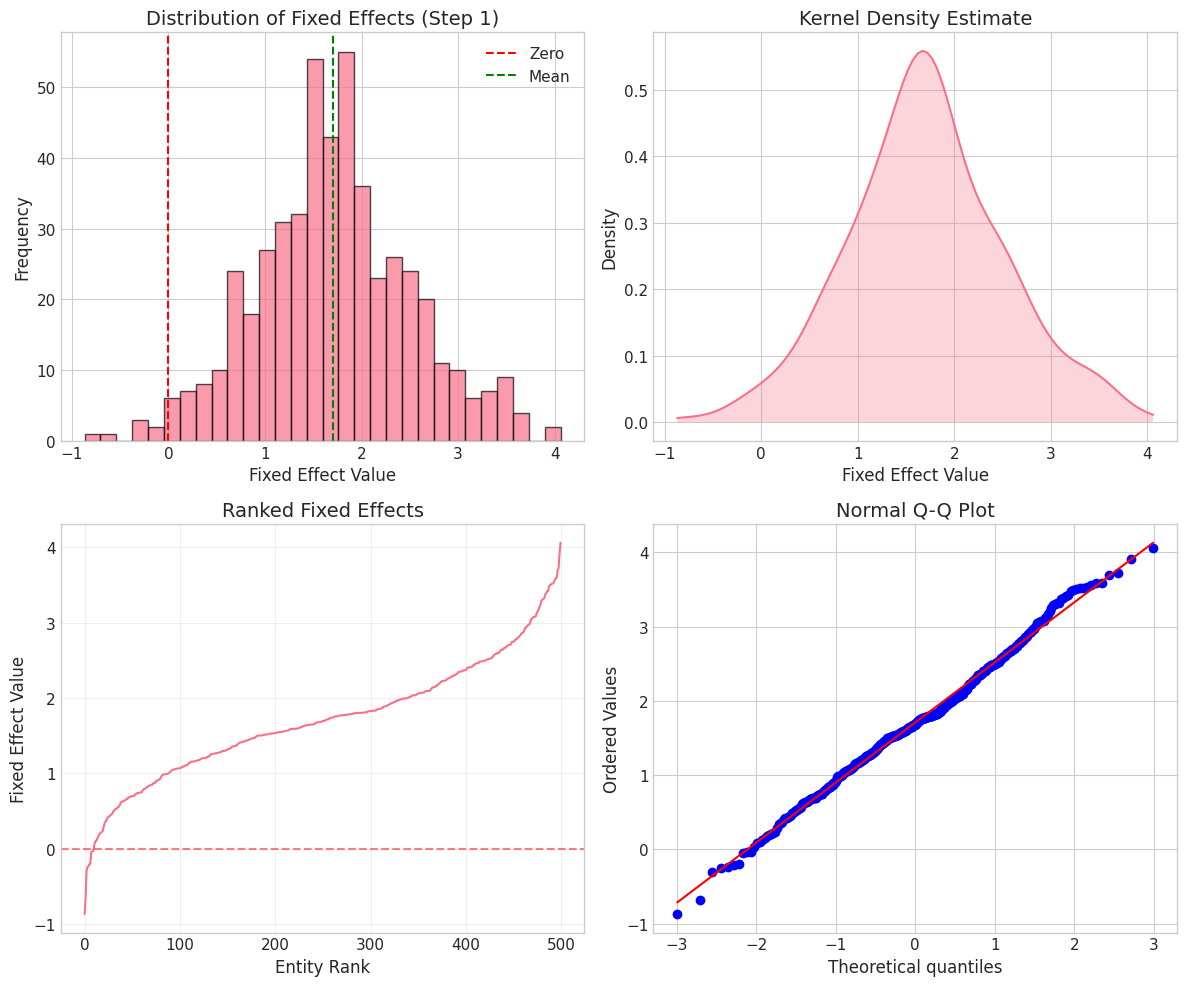


Worker Fixed Effects:
  N workers:  500
  Mean:       1.7089
  Std:        0.8068
  Min:        -0.8685
  Max:        4.0599

Interpretation: The worker fixed effects represent unobserved
time-invariant characteristics (ability, motivation, social networks).
Their distribution shows the extent of unobserved heterogeneity
in the labor market. A wide distribution suggests substantial
individual-level differences not captured by observables.


In [14]:
# Question 4: FE distribution interpretation

print("\n" + "=" * 70)
print("Q4: FIXED EFFECTS DISTRIBUTION")
print("=" * 70)

wage_fe = canay_wage[0.5].fixed_effects

fig = canay_wage[0.5].plot_fixed_effects_distribution()
plt.show()

print("\nWorker Fixed Effects:")
print(f"  N workers:  {len(wage_fe)}")
print(f"  Mean:       {np.mean(wage_fe):.4f}")
print(f"  Std:        {np.std(wage_fe):.4f}")
print(f"  Min:        {np.min(wage_fe):.4f}")
print(f"  Max:        {np.max(wage_fe):.4f}")

print("\nInterpretation: The worker fixed effects represent unobserved")
print("time-invariant characteristics (ability, motivation, social networks).")
print("Their distribution shows the extent of unobserved heterogeneity")
print("in the labor market. A wide distribution suggests substantial")
print("individual-level differences not captured by observables.")

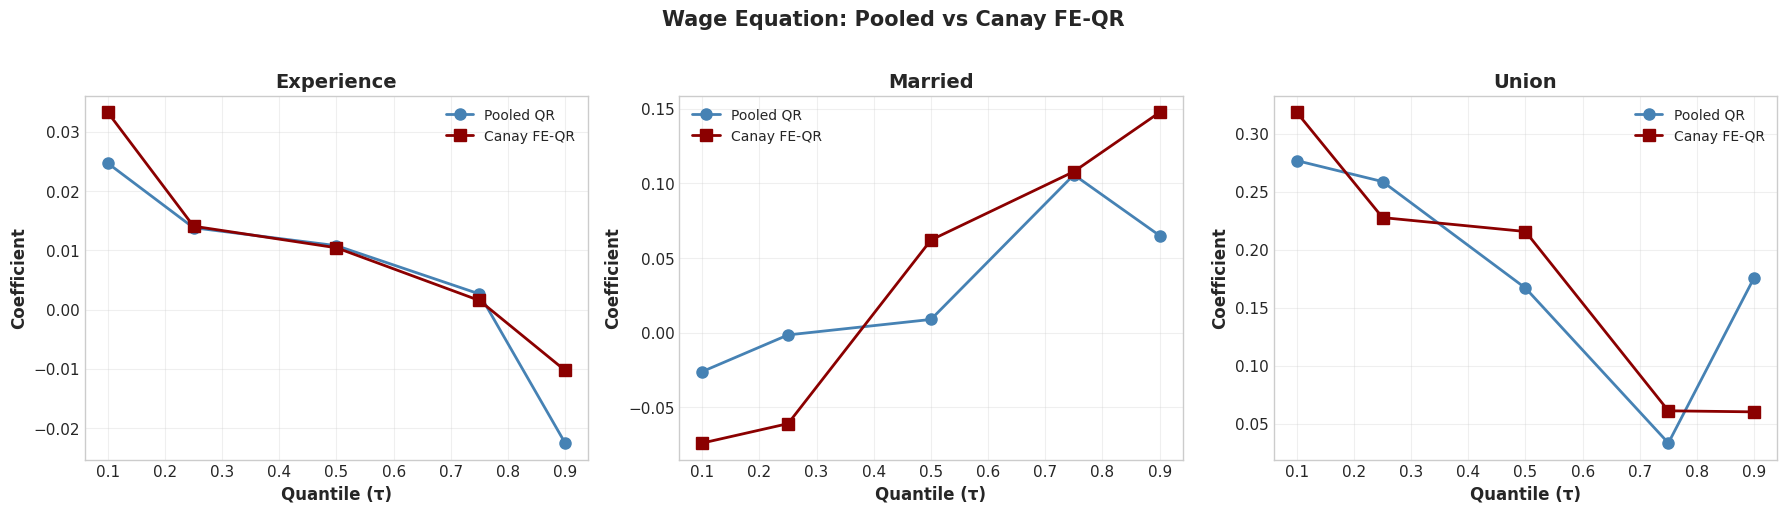


All exercises completed!


In [15]:
# Comprehensive comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (var_idx, var, label) in enumerate(
    [(1, "exper", "Experience"), (2, "married", "Married"), (3, "union", "Union")]
):
    pooled_coefs = [pooled_wage[tau].params.ravel()[var_idx] for tau in tau_wage]
    canay_coefs = [canay_wage[tau].results[tau].params[var_idx] for tau in tau_wage]

    axes[idx].plot(
        tau_wage,
        pooled_coefs,
        "o-",
        label="Pooled QR",
        linewidth=2,
        markersize=8,
        color="steelblue",
    )
    axes[idx].plot(
        tau_wage, canay_coefs, "s-", label="Canay FE-QR", linewidth=2, markersize=8, color="darkred"
    )

    axes[idx].set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("Coefficient", fontsize=12, fontweight="bold")
    axes[idx].set_title(f"{label}", fontsize=14, fontweight="bold")
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.suptitle("Wage Equation: Pooled vs Canay FE-QR", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nAll exercises completed!")